# CSC271 Final Project

##### Are opera and musical theatre companies in Canada experiencing declining attendance, performances, or ticket revenue between 2014 and 2024?

This project analyzes trends in attendance, number of performances, and ticket revenue for musical theatre and opera companies in Canada using data from Statistics Canada.

A project by **Laura Shehadi**



---
## 1. Project Questions

Inspired by the cultural claim mentioned by Timothée Chalamet that industries such as opera are "dying," this project investigates whether that claim holds up against data. Using Statistics Canada survey data on Canadian performing arts companies from 2014 to 2024, the following questions guide this analysis:

1. Has **attendance** at musical theatre and opera performances changed between 2014 and 2024?
2. Has the **number of performances** increased or decreased over time?
3. How has **ticket revenue** changed over time?
4. Do trends in **attendance correspond with changes in revenue** or number of performances?
5. How does attendance at musical theatre and opera **compare to other performing arts categories** (theatre, dance)?

---
## 2. Data Description

### Datasets

This project uses two datasets from Statistics Canada, both drawn from the Survey of Arts Organizations:

**Dataset 1 — Performances and Attendance (Table 21-10-0186-01)**  
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=2110018601  
Contains: total performances, total attendance, and average attendance per performance for performing arts companies in Canada, broken down by industry category (NAICS code) and year.

**Dataset 2 — Sources of Revenue (Table 21-10-0187-01)**  
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=2110018701  
Contains: detailed revenue sources (performance revenue, other sales, public sector funding, private sector funding, licensing) for the same performing arts categories and years.

Both datasets share the attributes `year` and NAICS industry category, which allows them to be joined. This analysis filters both datasets to the category **Musical theatre and opera companies [711112]**.

### Relevant Variables

| Variable | Source | Description |
|---|---|---|
| `year` | Both | Reference year (2014–2024, reported every two years) |
| `total_performances` | Attendance | Total number of performances given |
| `total_attendance` | Attendance | Total number of audience members |
| `avg_attendance_per_performance` | Attendance | Mean audience size per performance |
| `performance_revenue` | Revenue | Revenue earned from ticket sales (dollars) |
| `other_sales` | Revenue | Revenue from merchandise, concessions, etc. |
| `public_sector` | Revenue | Government grants and funding |
| `private_sector` | Revenue | Corporate sponsorships and donations |

### Preprocessing Notes

- Both raw CSVs are in **long format** (each metric is its own row). The cleaning functions pivot each dataset into wide format so that each year becomes one row with one column per metric.
- Revenue values in the raw data are reported in **thousands of dollars** and are multiplied by 1,000 during cleaning.
- `performance_revenue` and `other_sales` are **missing (NaN)** for 2016 in the raw data. These are kept as NaN rather than filled with zero, since zero would misrepresent the data.
- Data is reported **every two years** (2014, 2016, 2018, 2020, 2022, 2024), not annually.

### Database Schema

```text
attendance(year INTEGER PRIMARY KEY,
           total_performances REAL,
           total_attendance REAL,
           avg_attendance_per_performance REAL)

revenue(year INTEGER PRIMARY KEY,
        performance_revenue REAL,
        other_sales REAL,
        public_sector REAL,
        private_sector REAL,
        licensing_of_rights REAL)

```
The two tables are linked by `year`.

---
## 3. Analysis

In [30]:
import project as p
import pandas as pd

In [31]:
attendance_raw = p.load_data(p.ATTENDANCE_FILE)
attendance = p.clean_attendance(attendance_raw)

revenue_raw = p.load_data(p.REVENUE_FILE)
revenue = p.clean_revenue(revenue_raw)

attendance.head()
revenue.head()

,year,licensing_of_rights,other_sales,performance_revenue,private_sector,public_sector
0,2014,NaN,9557200.0,33282600.0,31876200.0,18092900.0
1,2016,NaN,NaN,NaN,29906600.0,18404700.0
2,2018,NaN,8674600.0,38277200.0,34744300.0,20590200.0
3,2020,0.0,2734100.0,16152800.0,29855200.0,25307700.0
4,2022,259900.0,4190500.0,19727600.0,31312400.0,29070100.0


In [32]:
conn = p.create_connection(p.DB_PATH)
p.create_tables(conn)
p.insert_data(conn, attendance, p.ATTENDANCE_TABLE)
p.insert_data(conn, revenue, p.REVENUE_TABLE)


---
### **Question 1:** Has attendance at musical theatre and opera performances changed?

To answer this question, I query the joined dataset, and examine attendance over time, both as raw numbers and as year-over-year percentage changes. I do this by using the `query_join_attendance_revenue()` and `compute_year_over_year_change()` functions from the `project.py` file

In [33]:
joined = p.query_join_attendance_revenue(conn)

joined[['year', 'total_attendance', 'avg_attendance_per_performance']]

,year,total_attendance,avg_attendance_per_performance
0,2014,1044456.0,460.0
1,2016,811605.0,437.0
2,2018,994720.0,369.0
3,2020,296759.0,351.0
4,2022,573442.0,297.0
5,2024,952485.0,321.0


In [34]:
attendance_change = p.compute_year_over_year_change(joined, 'total_attendance')

attendance_change[['year', 'total_attendance', 'total_attendance_change', 'total_attendance_pct_change']]

,year,total_attendance,total_attendance_change,total_attendance_pct_change
0,2014,1044456.0,NaN,NaN
1,2016,811605.0,-232851.0,-22.29
2,2018,994720.0,183115.0,22.56
3,2020,296759.0,-697961.0,-70.17
4,2022,573442.0,276683.0,93.23
5,2024,952485.0,379043.0,66.10


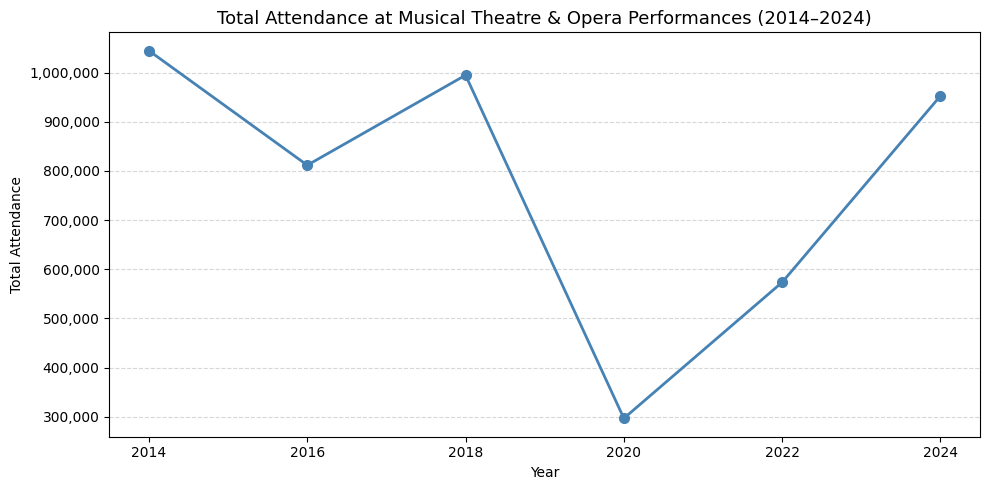

In [35]:
fig1 = p.plot_attendance_over_time(attendance)
fig1.savefig('attendance_over_time.png', dpi=150, bbox_inches='tight')

#### Results and Interpretations:

Attendance at musical theatre and opera performances was **1,044,456 in 2014**, making it the second-highest point in the study period. It then dropped to **811,605 in 2016**, a decline of roughly 232,000 audience members (−22%), which is notable even before the pandemic. Attendance partially recovered to **994,720 in 2018**, nearly returning to 2014 levels, suggesting that the 2016 dip was temporary rather than the start of a long-term decline.

The most dramatic shift occurs in 2020, where attendance collapsed to **296,759**, a loss of nearly 698,000 audience members compared to 2018, representing a −70% drop. This is clearly attributable to the COVID-19 pandemic, which forced widespread venue closures and cancellations across the performing arts sector.

The recovery since 2020 is striking. Attendance nearly doubled from 2020 to 2022 (+93%), and grew a further +66% from 2022 to 2024, reaching **952,485**, within 92,000 of the 2014 baseline. Notably, average attendance per performance tells a more nuanced story: it declined steadily from **460** per performance in 2014 to **321** in 2024, even as total attendance recovered. This suggests that while more performances are being staged, individual shows are drawing somewhat smaller crowds on average than they did a decade ago, something worth monitoring as a potential longer-term trend.

Overall, the data does not support the claim that musical theatre and opera attendance is in structural decline. The dominant pattern is a COVID-19 disruption followed by a strong recovery.


<br>

---
### **Question 2**: Has the number of performances increased or decreased over time?

Here, I examined whether the industry has been producing more or fewer performances across the study period, using the `compute_year_over_year_change()` function from the `project.py` file

In [36]:
perf_change = p.compute_year_over_year_change(joined, 'total_performances')

perf_change[['year', 'total_performances', 'total_performances_change', 'total_performances_pct_change']]

,year,total_performances,total_performances_change,total_performances_pct_change
0,2014,2272.0,NaN,NaN
1,2016,1857.0,-415.0,-18.27
2,2018,2693.0,836.0,45.02
3,2020,846.0,-1847.0,-68.59
4,2022,1933.0,1087.0,128.49
5,2024,2965.0,1032.0,53.39


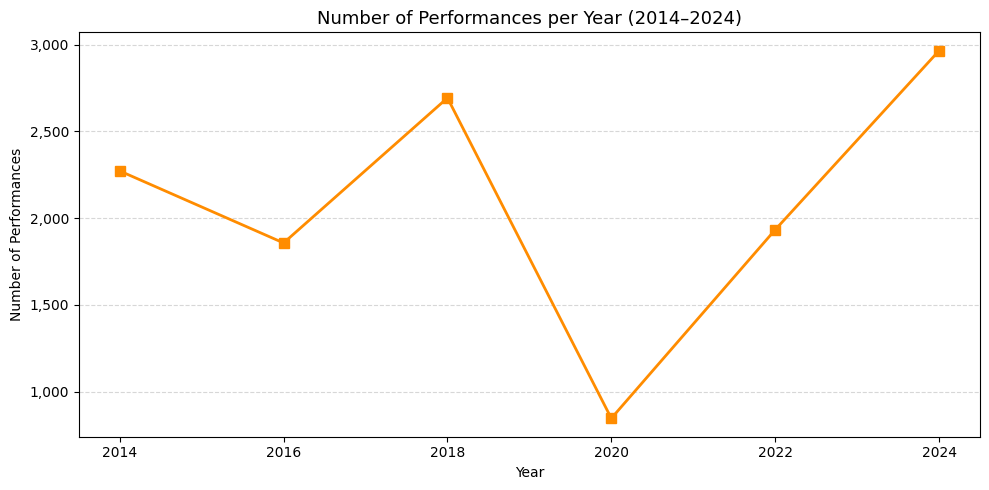

In [37]:
fig2 = p.plot_performances_over_time(attendance)
fig2.savefig('performances_over_time.png', dpi=150, bbox_inches='tight')

#### Results and Interpretation

The number of performances followed a pattern very similar to attendance. Starting at **2,272 performances in 2014**, it declined to **1,857 in 2016** (**−18%**), then rebounded strongly to a pre-pandemic high of **2,693 in 2018** (**+45%**). The pandemic hit hard in 2020, reducing performances to just **846**, a loss of nearly **1,847** shows, representing a **−69% drop**. Recovery was rapid: performances more than doubled from 2020 to 2022 (**+128%**), and grew a further **53%** by 2024, reaching **2,965**, the highest figure in the entire study period, surpassing even the 2018 peak.

This is a particularly meaningful finding. The fact that the number of performances in 2024 exceeds any previous year suggests that companies are not just recovering, but actively expanding their programming. This is difficult to reconcile with the idea of a "dying industry." However, when read alongside the average attendance per performance from Question 1, which declined from **460 in 2014** to **321 in 2024**, a more nuanced picture emerges: more shows are being staged, but individual performances are drawing smaller audiences on average. Whether this reflects a deliberate strategy of staging more accessible or smaller-scale productions, or whether it reflects difficulty filling seats, cannot be determined from this data alone.



<br>

---
### **Question 3**: How has ticket revenue changed over time?

In this section, I analyzed performance revenue (ticket sales) and total revenue from all sources combined, as a function of time. I did this by using the `GROUP BY` year with `SUM` using the `query_total_revenue_by_year()` function

In [38]:
total_revenue = p.query_total_revenue_by_year(conn)
total_revenue

,year,total_revenue
0,2014,92808900.0
1,2016,NaN
2,2018,102286300.0
3,2020,74049800.0
4,2022,84300600.0
5,2024,111950700.0


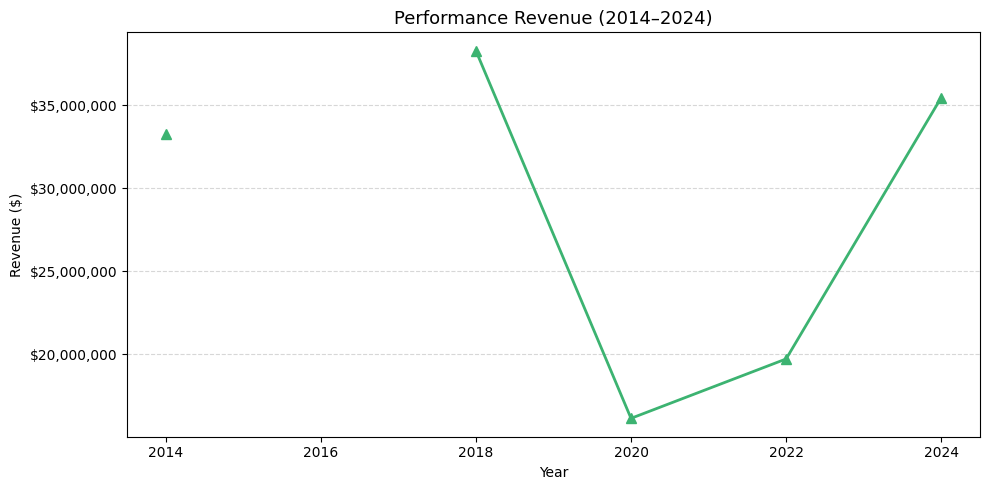

In [39]:
fig3 = p.plot_revenue_over_time(joined)
fig3.savefig('revenue_over_time.png', dpi=150, bbox_inches='tight')

#### Results and Interpretation

Performance revenue (ticket sales) was **$33.3M in 2014**, rose to a peak of **$38.3M in 2018**, then collapsed to **$16.2M in 2020**, less than half the 2018 level, as venues shut down during the pandemic. Revenue partially recovered to **$19.7M in 2022** and reached **$35.5M in 2024**, approaching but not yet surpassing the 2014 baseline.

The total revenue picture, which includes public sector grants, private sector donations, and other sources, tells a different and more optimistic story. Total revenue was **$92.8M in 2014**, was NaN in **2016** due to missing data, peaked at **$102.3M in 2018**, dropped to **$74.0M in 2020**, recovered to **$84.3M in 2022**, and reached its highest point in the entire study period at **$111.9M in 2024**. This suggests that while ticket sales have not yet fully recovered, the overall financial health of the sector has actually improved, likely driven by increased public and private funding. This distinction is important: an industry receiving record total revenue is not one that is dying, even if box office numbers have not yet returned to their 2018 peak.


<br>

---
### **Question 4**: Do trends in attendance correspond with changes in revenue?


To quantify whether attendance and revenue move together, I calculated the Pearson correlation coefficient (a measure of linear association I learned in PSY201). A value close to 1 indicates a strong positive relationship, meaning the two variables tend to rise and fall together. This is not a method from this course, but it is the standard way to measure how closely two variables track each other.

Here, I used a parameterized query to retrieve data from 2018 onward, then compute the Pearson correlation between attendance and performance revenue across all years. I use 2018 as the starting year because 2016 has missing revenue values in the raw data, making it an unreliable point for comparison. This query also demonstrates the parameterized query feature, where the start year can be adjusted as needed.


In [40]:
post_2018 = p.query_from_year(conn, 2018)
print(post_2018)

correlation = p.compute_correlation(joined, 'total_attendance', 'performance_revenue')


print(f'\n The correlation coefficient of attendance vs performance revenue = {correlation:.3f}')

   year  total_performances  total_attendance  performance_revenue
0  2018              2693.0          994720.0           38277200.0
1  2020               846.0          296759.0           16152800.0
2  2022              1933.0          573442.0           19727600.0
3  2024              2965.0          952485.0           35455200.0

 The correlation coefficient of attendance vs performance revenue = 0.955


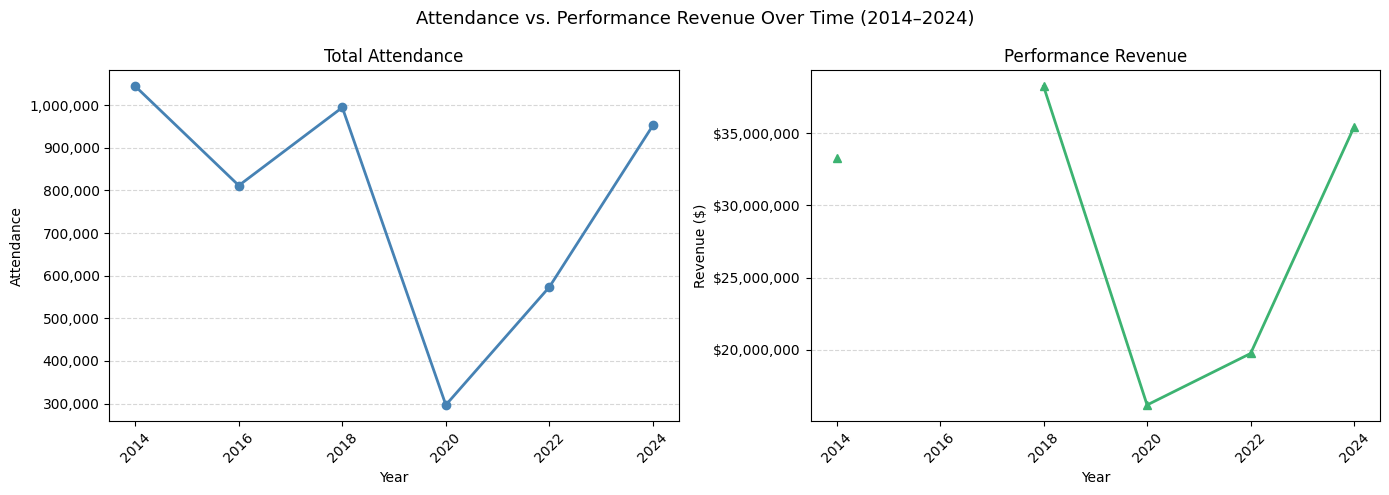

In [41]:
fig4 = p.plot_attendance_vs_revenue(joined)
fig4.savefig('attendance_vs_revenue.png', dpi=150, bbox_inches='tight')

#### Results and Interpretation

The Pearson correlation coefficient between total attendance and performance revenue across all years is **0.955**, indicating a very strong positive linear relationship. This means that years with high attendance almost always correspond to high ticket revenue, and years with low attendance correspond to low revenue, which is intuitive, since ticket sales are directly tied to how many people attend.

The side-by-side visualization makes this relationship immediately visible: both curves follow the exact same shape, a rise to **2018**, a sharp collapse in **2020**, and a recovery through **2022** and **2024**. The one notable divergence is **2016**, where attendance dropped but revenue held relatively steady, though the **2016** revenue data has missing values which limits interpretation for that year.

One important note: correlation does not imply causation, and with only **6** data points, one per reporting period, the correlation value should be interpreted with some caution. That said, the visual and numerical evidence together strongly suggest that audience size is the primary driver of ticket revenue for this sector.


<br>

---
### **Question 5**: How does musical theatre and opera attendance compare to other performing arts?

To determine whether any decline or recovery is unique to musical theatre and opera, I compare its attendance trajectory against two other performing arts categories from the same Statistics Canada dataset. All three categories are classified under the North American Industry Classification System (NAICS): Musical theatre and opera companies, Theatre (except musical) companies, and Dance companies. By comparing these three, I can assess whether any trends are specific to musical theatre and opera or reflect a broader pattern across the performing arts sector.



In [42]:
categories = {
    'Musical Theatre & Opera': p.TARGET_NAICS,
    'Theatre (non-musical)': p.THEATRE_NAICS,
    'Dance': p.DANCE_NAICS,
}

comparison_rows = []

for label, naics in categories.items():
    subset = p.filter_naics(attendance_raw, naics)

    subset_att = subset[
        subset[p.RAW_ATT_METRIC] == p.RAW_TOTAL_ATTENDANCE
    ][['REF_DATE', 'VALUE']].copy()

    subset_att.columns = ['year', label]
    subset_att = subset_att.set_index('year')

    comparison_rows.append(subset_att)

comparison_df = pd.concat(comparison_rows, axis=1).reset_index()
comparison_df

,year,Musical Theatre & Opera,Theatre (non-musical),Dance
0,2014,1044456.0,6446605.0,767673.0
1,2016,811605.0,6774807.0,817610.0
2,2018,994720.0,7292855.0,1116969.0
3,2020,296759.0,3191385.0,651380.0
4,2022,573442.0,3646585.0,670563.0
5,2024,952485.0,5185704.0,916608.0


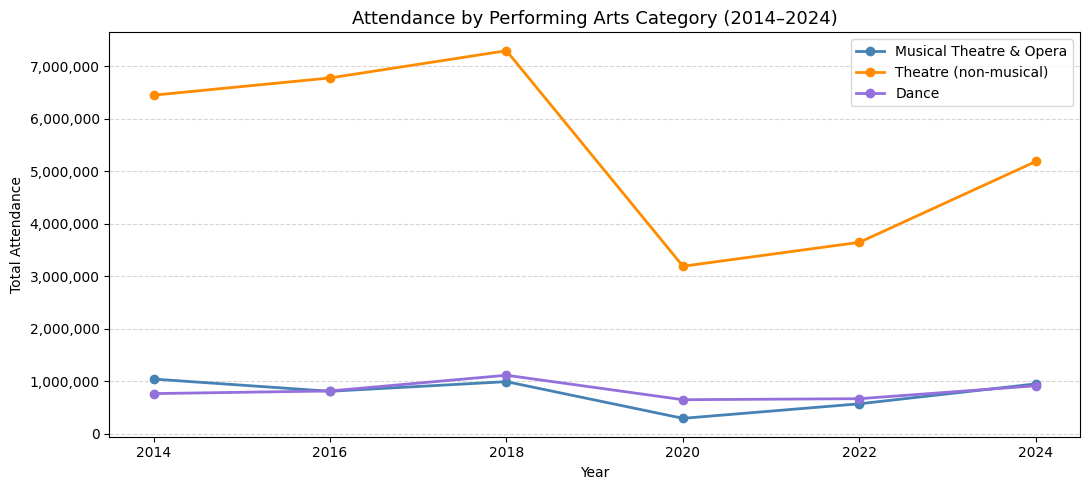

In [43]:
fig5 = p.plot_attendance_comparison(attendance_raw)
fig5.savefig('attendance_comparison.png', dpi=150, bbox_inches='tight')

#### Results and Interpretation

The comparison across the three NAICS categories reveals two clear patterns. First, all three categories, Musical Theatre and Opera, Theatre (non-musical), and Dance, experienced the same dramatic drop in **2020** and have been recovering since, confirming that the COVID-19 disruption was a sector-wide phenomenon rather than something specific to musical theatre and opera.

Second, the three categories operate at very different scales. Theatre (non-musical) dominates with attendance ranging from roughly **3.2M (2020)** to **7.3M (2018)**, while Musical Theatre and Opera and Dance are in a comparable and much smaller range under **1.2M**. This means the line chart should be read carefully, the visual proximity of the Musical Theatre and Opera and Dance lines is a result of their similar scale, not necessarily similar trends.

Looking at recovery relative to each category's own **2014** baseline is more revealing. Musical Theatre and Opera recovered to **952,485 in 2024**, which is **91%** of its **2014** level. Dance recovered to **916,608**, which is **119%** of its **2014** level, a full recovery and then some. Theatre (non-musical), despite its much larger absolute numbers, recovered to only **5,185,704 in 2024**, which is **80%** of its **2014** level of **6,446,605**, the weakest relative recovery of the three. This suggests that musical theatre and opera is actually recovering more robustly than the largest category in the sector, further undermining the claim that it is a dying industry.

<br>

---
## 4. Results and Interpretation

Taken together, the five analyses paint a consistent picture: the dominant feature of the 2014–2024 period is not structural decline, but a COVID-19 disruption followed by a robust recovery across all three dimensions measured, attendance, number of performances, and revenue. By 2024, total performances ($\textbf{2,965}$) exceeded any previous year in the study period, attendance ($\textbf{952,485}$) nearly matched its 2014 baseline, and total revenue ($\$\textbf{111.9}\textbf{M}$) reached its highest point on record. These are not the indicators of a dying industry.

The strong Pearson correlation between attendance and performance revenue ($r = \textbf{0.955}$) reveals that these two variables function as a single system: when audiences return, revenue follows. The cross-category comparison reinforces that the 2020 collapse and subsequent recovery were sector-wide phenomena driven by the pandemic, rather than trends unique to musical theatre and opera. If anything, musical theatre and opera is recovering more robustly than Theatre (non-musical) relative to its own 2014 baseline ($\textbf{91\%}$ vs. $\textbf{80\%}$ recovered).

The one finding worth monitoring is the steady decline in average attendance per performance, from $\textbf{460}$ in 2014 to $\textbf{321}$ in 2024, which sits beneath the otherwise positive headline numbers. More performances are being staged than ever, but individual shows are drawing smaller crowds on average. Whether this reflects a strategic shift toward more accessible or smaller-scale productions, or a gradual difficulty in filling seats, cannot be determined from this data alone, but it is the most meaningful signal of a potential longer-term trend worth watching.

---
## 5. Conclusions

**Question 1: Has attendance changed between 2014 and 2024?**  
Yes, but the dominant pattern is recovery rather than decline. By 2024, attendance had nearly returned to its 2014 baseline following the COVID-19 collapse of 2020.

**Question 2: Has the number of performances changed over time?**  
Performances in 2024 ($\textbf{2,965}$) exceeded every previous year in the study period, including the pre-pandemic peak. Companies are staging more productions than ever.

**Question 3: How has ticket revenue changed over time?**  
Performance revenue has not yet returned to its 2018 peak, but total revenue from all sources reached $\$\textbf{111.9M}$ in 2024, the highest on record, driven by increased public and private sector funding.

**Question 4: Do attendance and revenue move together?**  
Yes. With $r = \textbf{0.955}$, the two variables are very strongly correlated, confirming that audience size is the primary driver of ticket income.

**Question 5: How does musical theatre and opera compare to other performing arts?**  
All three categories were equally disrupted in 2020 and are all recovering. Musical theatre and opera's recovery relative to its 2014 baseline ($\textbf{91\%}$) is stronger than Theatre (non-musical) ($\textbf{80\%}$) and comparable to Dance ($\textbf{119\%}$).

**Overall:** The data does not support the claim that musical theatre and opera are dying industries. The sector has demonstrated clear resilience, with the declining average attendance per performance being the one signal worth continued monitoring.

<br>

### Limitations

**Reporting frequency:** Data is collected and reported every two years rather than annually, meaning any short-term fluctuations or trends that occur within a reporting period are completely invisible. For example, if attendance began recovering in 2021, this would not be captured, the data jumps directly from the 2020 collapse to the 2022 figure, making the recovery appear more sudden than it may have been in reality.

**Level of aggregation:** The data is aggregated at the national level across all musical theatre and opera companies in Canada. This means regional differences, for example, whether companies in Toronto are thriving while those in smaller cities are struggling, cannot be examined. Similarly, individual company performance is entirely obscured, so a small number of very successful companies could be masking declines elsewhere in the sector.

**Missing variables:** The dataset captures attendance and revenue but does not include factors that may be equally important to long-term sustainability, such as audience demographics, average ticket prices, production costs, or the number of active companies over time. Without these, it is difficult to determine whether the recovery in attendance and revenue reflects genuine renewed public interest or other structural changes in how the industry operates.

**Missing data for 2016:** Performance revenue and other sales are recorded as `NaN` for 2016 in the raw data, which affects year-over-year calculations for that period and means total revenue for 2016 cannot be computed. The reason for this gap is not documented in the Statistics Canada dataset.

**COVID-19 as an outlier:** The 2020 data point represents an extraordinary external disruption with no precedent in the study period. Its inclusion significantly influences correlation results and trend calculations throughout the analysis. Without 2020, the correlation between attendance and revenue would be based on far less variation, and the year-over-year change calculations would look very different. Any conclusions drawn from this dataset should be understood in the context of this outlier.


In [44]:
plot_attendance_over_time(att).savefig('images/attendance.png')
plot_performances_over_time(att).savefig('images/performances.png')
plot_revenue_over_time(rev).savefig('images/revenue.png')
plot_attendance_vs_revenue(joined).savefig('images/attendance_vs_revenue.png')
plot_attendance_comparison(att_raw).savefig('images/comparison.png')

NameError: name 'plot_attendance_over_time' is not defined